PCA

In [1]:
import numpy as np

X_train = np.load("X_train_phaseA.npy")
y_train = np.load("y_train_phaseA.npy")

X_val   = np.load("X_val_phaseA.npy")
y_val   = np.load("y_val_phaseA.npy")

X_test  = np.load("X_test_phaseA.npy")
y_test  = np.load("y_test_phaseA.npy")


In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

In [3]:
print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {X_train_pca.shape[1]}")
print("Explained variance:", sum(pca.explained_variance_ratio_))

Original number of features: 384
Reduced number of features: 197
Explained variance: 0.95057076


In [5]:
import joblib

# Save fitted PCA transformer
joblib.dump(pca, "models/pca_transformer.pkl")
print("PCA saved — components:", pca.n_components_)

PCA saved — components: 197


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train_pca))
val_acc   = accuracy_score(y_val, clf.predict(X_val_pca))

print("PCA + LR Train acc:", train_acc)
print("PCA + LR Val acc  :", val_acc)



PCA + LR Train acc: 1.0
PCA + LR Val acc  : 0.9246575342465754


In [7]:
np.save("X_train_pca.npy", X_train_pca)
np.save("X_val_pca.npy",   X_val_pca)
np.save("X_test_pca.npy",  X_test_pca)


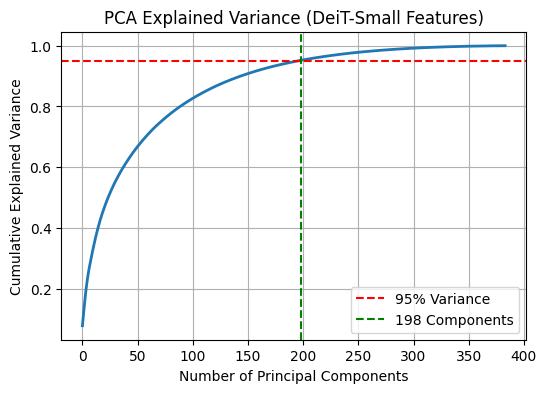

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca_full = PCA()
pca_full.fit(X_train)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(cum_var, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=198, color='g', linestyle='--', label='198 Components')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (DeiT-Small Features)")
plt.legend()
plt.grid(True)
plt.show()


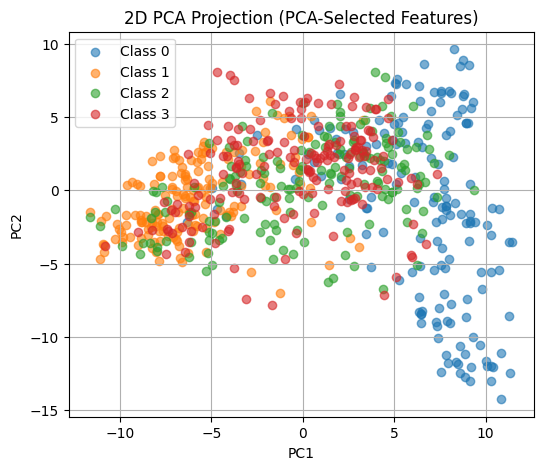

In [7]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_pca)

plt.figure(figsize=(6, 5))
for cls in np.unique(y_train):
    plt.scatter(
        X_train_2d[y_train == cls, 0],
        X_train_2d[y_train == cls, 1],
        label=f"Class {cls}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (PCA-Selected Features)")
plt.legend()
plt.grid(True)
plt.show()


MI

In [10]:
import numpy as np

X_train = np.load("X_train_phaseA.npy")
y_train = np.load("y_train_phaseA.npy")

X_val = np.load("X_val_phaseA.npy")
y_val = np.load("y_val_phaseA.npy")

X_test = np.load("X_test_phaseA.npy")
y_test = np.load("y_test_phaseA.npy")


In [11]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

# Rank features by MI score (descending)
mi_ranked_idx = np.argsort(mi_scores)[::-1]


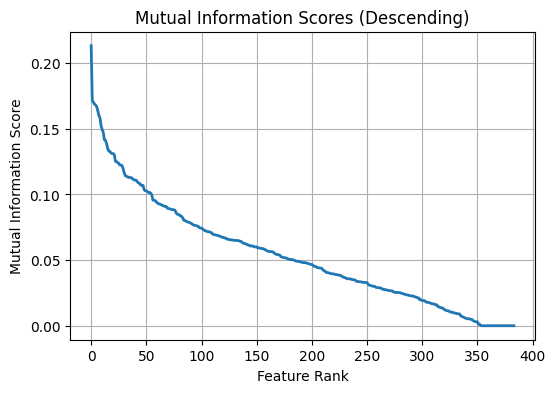

In [12]:
import matplotlib.pyplot as plt

sorted_mi = np.sort(mi_scores)[::-1]

plt.figure(figsize=(6,4))
plt.plot(sorted_mi, linewidth=2)
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information Score")
plt.title("Mutual Information Scores (Descending)")
plt.grid(True)
plt.show()


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

feature_steps = range(20, 301, 20)

best_k = None
best_val_acc = 0
results = []

for k in feature_steps:
    selected_idx = mi_ranked_idx[:k]

    Xtr_sel = X_train[:, selected_idx]
    Xval_sel = X_val[:, selected_idx]

    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr_sel, y_train)

    val_acc = accuracy_score(y_val, clf.predict(Xval_sel))
    results.append((k, val_acc))

    print(f"Top-{k} MI features → Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k


Top-20 MI features → Val Acc: 0.7945
Top-40 MI features → Val Acc: 0.7945
Top-60 MI features → Val Acc: 0.8151
Top-80 MI features → Val Acc: 0.8288
Top-100 MI features → Val Acc: 0.8904
Top-120 MI features → Val Acc: 0.8904
Top-140 MI features → Val Acc: 0.8562
Top-160 MI features → Val Acc: 0.8630
Top-180 MI features → Val Acc: 0.8904
Top-200 MI features → Val Acc: 0.9110
Top-220 MI features → Val Acc: 0.9110
Top-240 MI features → Val Acc: 0.9178
Top-260 MI features → Val Acc: 0.9315
Top-280 MI features → Val Acc: 0.9247
Top-300 MI features → Val Acc: 0.9178


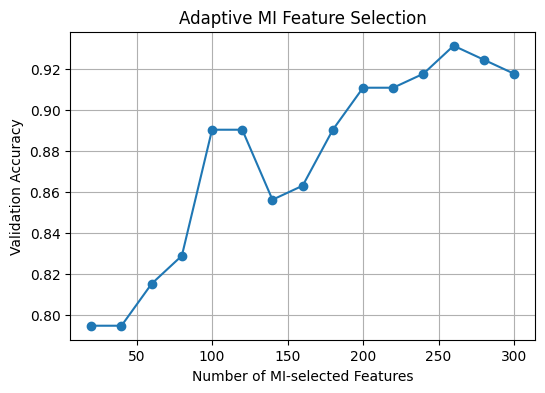

In [14]:
ks, accs = zip(*results)

plt.figure(figsize=(6,4))
plt.plot(ks, accs, marker='o')
plt.xlabel("Number of MI-selected Features")
plt.ylabel("Validation Accuracy")
plt.title("Adaptive MI Feature Selection")
plt.grid(True)
plt.show()


In [15]:
print("Optimal number of MI features:", best_k)
print("Best validation accuracy:", best_val_acc)

selected_idx = mi_ranked_idx[:best_k]

X_train_mi = X_train[:, selected_idx]
X_val_mi   = X_val[:, selected_idx]
X_test_mi  = X_test[:, selected_idx]


Optimal number of MI features: 260
Best validation accuracy: 0.9315068493150684


In [ ]:
import joblib
joblib.dump(selected_idx, "models/mi_selected_idx.pkl")
print(f"MI selector saved — {len(selected_idx)} features selected.")

MI selector saved — 260 features selected.


In [18]:
np.save("X_train_mi.npy", X_train_mi)
np.save("X_val_mi.npy",   X_val_mi)
np.save("X_test_mi.npy",  X_test_mi)


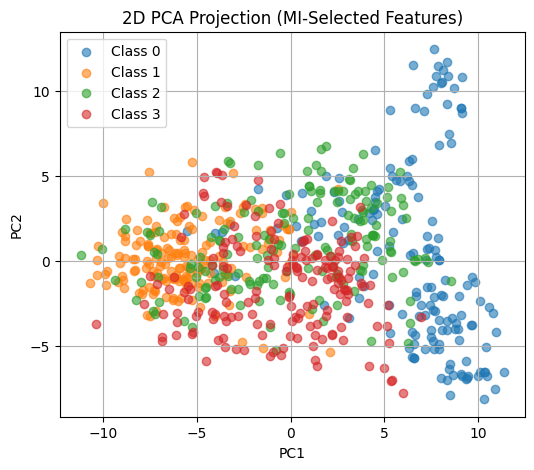

In [19]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_train_mi_2d = pca_2d.fit_transform(X_train_mi)

plt.figure(figsize=(6,5))
for cls in np.unique(y_train):
    plt.scatter(
        X_train_mi_2d[y_train == cls, 0],
        X_train_mi_2d[y_train == cls, 1],
        label=f"Class {cls}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (MI-Selected Features)")
plt.legend()
plt.grid(True)
plt.show()


BORUTA

In [20]:
import numpy as np

X_train = np.load("X_train_phaseA.npy")
y_train = np.load("y_train_phaseA.npy")

X_val = np.load("X_val_phaseA.npy")
y_val = np.load("y_val_phaseA.npy")

X_test = np.load("X_test_phaseA.npy")
y_test = np.load("y_test_phaseA.npy")


In [21]:
pip install boruta


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier


In [23]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [24]:
boruta = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    perc=100,
    max_iter=100,
    random_state=42
)

boruta.fit(X_train, y_train)


,estimator,RandomForestC...0x1FF5E514A40)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M... 0x1FF5E514A40
,verbose,0
,early_stopping,False
,n_iter_no_change,20
,n_estimators,242


In [25]:
selected_mask = boruta.support_
selected_features = np.where(selected_mask)[0]

print("Total original features:", X_train.shape[1])
print("Boruta selected features:", len(selected_features))


Total original features: 384
Boruta selected features: 250


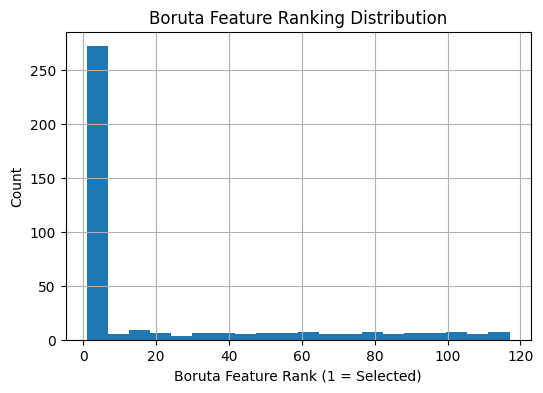

In [26]:
import matplotlib.pyplot as plt

ranks = boruta.ranking_

plt.figure(figsize=(6,4))
plt.hist(ranks, bins=20)
plt.xlabel("Boruta Feature Rank (1 = Selected)")
plt.ylabel("Count")
plt.title("Boruta Feature Ranking Distribution")
plt.grid(True)
plt.show()


In [27]:
X_train_boruta = X_train[:, selected_features]
X_val_boruta   = X_val[:, selected_features]
X_test_boruta  = X_test[:, selected_features]


In [ ]:
#Save Boruta
import joblib
joblib.dump(selected_features, "models/boruta_selected_features.pkl")
print(f"Boruta selector saved — {len(selected_features)} features selected.")

Boruta selector saved — 250 features selected.


In [29]:
np.save("X_train_boruta.npy", X_train_boruta)
np.save("X_val_boruta.npy",   X_val_boruta)
np.save("X_test_boruta.npy",  X_test_boruta)


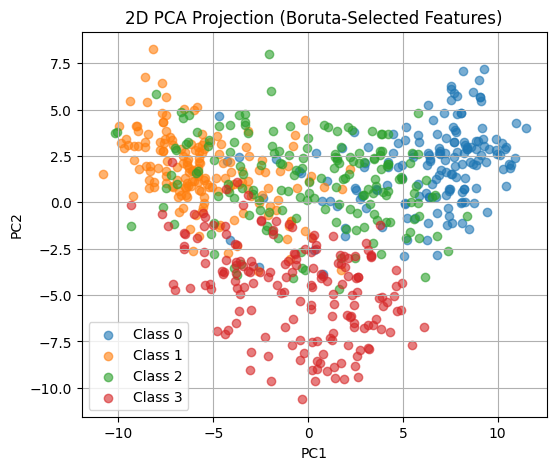

In [30]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_train_boruta_2d = pca_2d.fit_transform(X_train_boruta)

plt.figure(figsize=(6,5))
for cls in np.unique(y_train):
    plt.scatter(
        X_train_boruta_2d[y_train == cls, 0],
        X_train_boruta_2d[y_train == cls, 1],
        label=f"Class {cls}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (Boruta-Selected Features)")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_boruta, y_train)

val_acc = accuracy_score(y_val, clf.predict(X_val_boruta))
print("Boruta + LR Val Accuracy:", val_acc)


Boruta + LR Val Accuracy: 0.9383561643835616
